# Task 1.3 - Data Augmentation and Robustness (notebook-first)

Development sandbox for Task 1.3. Goal: make the Task 1.2 detector robust to realistic distortions (scale, JPEG compression, blur, noise).

Targets: `recall_ai >= 0.60` on `data/validation_augmented/` with `fpr_real <= 0.20`, keeping `data/validation/` competitive. Same CPU budget as Task 1.2 (5x Appendix-C reference). Fine-tune from `artifacts/task02/best.pt`.

Once the targets are cleared here, the recipe ports to `_lib/`, `prepare.py`, `train_augmented.py`, `predict_augmented.py`. Findings/decisions are logged to `task13_experiment_log.md`.

## B.0 - Setup and budget

Load the prepared uint8 caches (same `artifacts/prepared/` produced by `prepare.py`, the splits `train.py` consumes), the Task 2 artifacts (`best.pt`, `rf_model.pkl`, `threshold.json`), and the cached Appendix-C reference time. Budget for augmented training = 5x reference, identical to Task 1.2.

In [1]:
import os, sys, time, json
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
sys.path.insert(0, "../solution")

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from sklearn.metrics import roc_auc_score

from _lib import seed as _seed
from _lib import io as _io
from _lib.calibration import pick_threshold_for_fpr
from _lib.model import build_cnn_bn, cnn_scores, class_weights, batch_to_chw, FocalLoss
from _lib.features import features_from_uint8

torch.set_num_threads(min(8, os.cpu_count() or 1))
torch.set_num_interop_threads(1)

PREP    = Path("../solution/artifacts/prepared")
NBCACHE = Path("../solution/artifacts/notebook_cache")
TASK02  = Path("../solution/artifacts/task02")
DATA    = Path("../solution/data")
IMG_SIZE = 224
TRAIN_IMG_SIZE = 160
CNN_K = 16

# 5x Appendix-C reference budget (same machine/value as Task 1.2)
REF_S = json.loads((NBCACHE / "budget.json").read_text())["reference_elapsed_s"]
BUDGET_S = 5.0 * REF_S
print(f"reference={REF_S:.1f}s  ->  5x budget={BUDGET_S:.0f}s")

def load_split(name):
    n   = int(np.load(PREP / f"n_{name}.npy")[0])
    X   = np.lib.format.open_memmap(str(PREP / f"X_{name}.mmap"), mode="r",
                                     dtype=np.uint8, shape=(n, IMG_SIZE, IMG_SIZE, 3))
    y   = np.load(PREP / f"y_{name}.npy")
    src = np.load(PREP / f"src_{name}.npy")
    Ff  = np.load(PREP / f"F_{name}.npy")
    return X, y, src, Ff

print("loading prepared splits...")
X_fit,  y_fit,  src_fit,  F_fit  = load_split("fit")
X_hold, y_hold, src_hold, F_hold = load_split("hold")
X_cal,  y_cal,  src_cal,  F_cal  = load_split("cal")
X_val,  y_val,  src_val,  F_val  = load_split("val")
X_va,   y_va,   src_va,   F_va   = load_split("va")
mean = np.load(PREP / "mean.npy")
std  = np.load(PREP / "std.npy")
print(f"fit={len(X_fit)}  hold={len(X_hold)}  cal={len(X_cal)}  val={len(X_val)}  va={len(X_va)}")

# Task 2 artifacts
import joblib
ckpt = torch.load(str(TASK02 / "best.pt"), map_location="cpu", weights_only=False)
cnn_t2 = build_cnn_bn(k=ckpt["k"]); cnn_t2.load_state_dict(ckpt["state"]); cnn_t2.eval()
rf_t2  = joblib.load(str(TASK02 / "rf_model.pkl"))
thr_t2 = json.loads((TASK02 / "threshold.json").read_text())
print(f"task02 loaded: k={ckpt['k']} img_size={ckpt['img_size']} alpha={thr_t2['alpha']} thr={thr_t2['thr']:.4f}")


reference=155.6s  ->  5x budget=778s
loading prepared splits...
fit=26718  hold=2970  cal=1924  val=1124  va=1124
task02 loaded: k=16 img_size=160 alpha=0.4 thr=0.6770


c:\Users\Agando\anaconda3\envs\amls2026\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Agando\anaconda3\envs\amls2026\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## B.1 - Load augmented calibration split

The augmentation strategy used below is justified empirically in the companion analysis notebook `04_task13_aug_analysis.ipynb`, which inspects `data/calibration_augmented/` (visuals + metric distributions + forward-matching of candidate transforms) and records its conclusions in `task13_experiment_log.md`. Here we only decode `calibration_augmented` (not in the prepared cache) for the threshold calibration in B.8.

In [2]:
def decode_split_uint8(split_name):
    """Decode a data/ split to a cached uint8 (N,224,224,3) array + binary labels."""
    xp = NBCACHE / f"{split_name}_x.uint8.npy"
    yp = NBCACHE / f"{split_name}_y.npy"
    if xp.exists() and yp.exists():
        return np.load(xp), np.load(yp)
    imgs, labs = [], []
    for b, lab in _io.read_parquet_split(DATA / split_name):
        arr = _io.clean_image(b)
        if arr is None:
            continue
        imgs.append((arr * 255.0 + 0.5).astype(np.uint8))
        labs.append(0 if lab == 0 else 1)
    X = np.stack(imgs); yv = np.array(labs, dtype=np.int64)
    np.save(xp, X); np.save(yp, yv)
    return X, yv

X_ca, y_ca = decode_split_uint8("calibration_augmented")
print(f"calibration_augmented: n={len(X_ca)}  real={int((y_ca==0).sum())}  ai={int((y_ca==1).sum())}")


calibration_augmented: n=1924  real=321  ai=1603


## B.2 - Augmentation pipeline and cost

The augmentation, justified by `04_task13_aug_analysis.ipynb`, is applied **on the fly during training** (per batch, in memory) and never stored as a new split. It operates on cleaned uint8 224x224 images before normalization, so it composes with `batch_to_chw`.

Design (per image, random, matching the observed mixture): horizontal flip; random downscale-upscale; random Gaussian blur; mild brightness/contrast jitter; random JPEG re-encode (mostly moderate quality, occasional heavy). We cover the observed family (JPEG / blur / downscale) with somewhat broader ranges rather than precision-fitting the provided parameters, for general robustness with margin (see experiment log decision).

Cost matters: the JPEG re-encode via PIL is the expensive op, and per-batch augmentation reduces how many gradient steps fit in the budget. This cell measures the per-batch overhead.

In [3]:
import io as _stdio
from PIL import Image, ImageFilter, ImageEnhance

# Candidate training augmentation (per-image, random). Ranges from notebook 04 analysis,
# broadened slightly for general robustness. This is the prototype for the _lib port.
AUG = dict(p_flip=0.5, p_down=0.30, down=(0.65, 0.92), p_blur=0.40, blur=(0.3, 1.0),
           p_photo=0.30, photo=(0.90, 1.10), p_jpeg=0.65, q_main=(40, 90),
           p_heavy=0.25, q_heavy=(10, 40))

def augment_one(img_u8, rng, P=AUG):
    """Augment one cleaned uint8 (224,224,3) image; returns uint8 (224,224,3)."""
    im = Image.fromarray(img_u8)
    if rng.random() < P["p_flip"]:
        im = im.transpose(Image.FLIP_LEFT_RIGHT)
    if rng.random() < P["p_down"]:
        f = rng.uniform(*P["down"]); w = im.width
        im = im.resize((max(1, int(w*f)),)*2, Image.BILINEAR).resize((w, w), Image.BILINEAR)
    if rng.random() < P["p_blur"]:
        im = im.filter(ImageFilter.GaussianBlur(rng.uniform(*P["blur"])))
    if rng.random() < P["p_photo"]:
        im = ImageEnhance.Brightness(im).enhance(rng.uniform(*P["photo"]))
        im = ImageEnhance.Contrast(im).enhance(rng.uniform(*P["photo"]))
    if rng.random() < P["p_jpeg"]:
        q = int(rng.uniform(*P["q_heavy"])) if rng.random() < P["p_heavy"] else int(rng.uniform(*P["q_main"]))
        b = _stdio.BytesIO(); im.save(b, "JPEG", quality=q); im = Image.open(b).convert("RGB")
    return np.asarray(im, dtype=np.uint8)

def augment_batch(X_u8, rng, P=AUG):
    """Augment a uint8 (N,224,224,3) batch in memory; returns a new uint8 array."""
    out = np.empty_like(X_u8)
    for i in range(len(X_u8)):
        out[i] = augment_one(X_u8[i], rng, P)
    return out

# cost: per-batch augmentation overhead vs a 160px train step
rng_c = np.random.default_rng(0)
xb = X_fit[np.arange(64)]
_ = augment_batch(xb, rng_c)                       # warmup
t0 = time.monotonic()
for _ in range(5):
    augment_batch(xb, rng_c)
aug_s = (time.monotonic() - t0) / 5

cnn_tmp = build_cnn_bn(k=CNN_K)
opt_tmp = torch.optim.AdamW(cnn_tmp.parameters(), lr=3e-4)
xt = batch_to_chw(np.arange(64), xb, mean, std, target_size=TRAIN_IMG_SIZE)
yt = torch.zeros(64, dtype=torch.long)
lf = FocalLoss(gamma=1.5)
for _ in range(2):
    opt_tmp.zero_grad(); lf(cnn_tmp(xt), yt).backward(); opt_tmp.step()   # warmup
t0 = time.monotonic()
for _ in range(5):
    opt_tmp.zero_grad(); lf(cnn_tmp(xt), yt).backward(); opt_tmp.step()
step_s = (time.monotonic() - t0) / 5

print(f"augment_batch(64): {aug_s*1000:.0f} ms/batch")
print(f"train step (64, 160px): {step_s*1000:.0f} ms/batch")
print(f"augmentation overhead: +{100*aug_s/step_s:.0f}% per step  "
      f"(~{aug_s/(aug_s+step_s)*100:.0f}% of wall time)")


augment_batch(64): 72 ms/batch
train step (64, 160px): 491 ms/batch
augmentation overhead: +15% per step  (~13% of wall time)


### B.2.1 - Visualize our augmentation and check it matches the provided shift

Three views, all on the **same** clean image where possible (this is *our* augmentation, applied by us):
1. Strength strip: one clean image under each individual transform, so the effect of each is visible.
2. Paired before/after: clean original (top) vs our random augmentation of the same image (bottom).
3. Population check: our augmented reals vs the provided augmented reals, plus a metric comparison (high-frequency power, noise, near-clean fraction) to confirm we reproduce the provided shift without precision-fitting it. Figures saved to `report/figures/`.

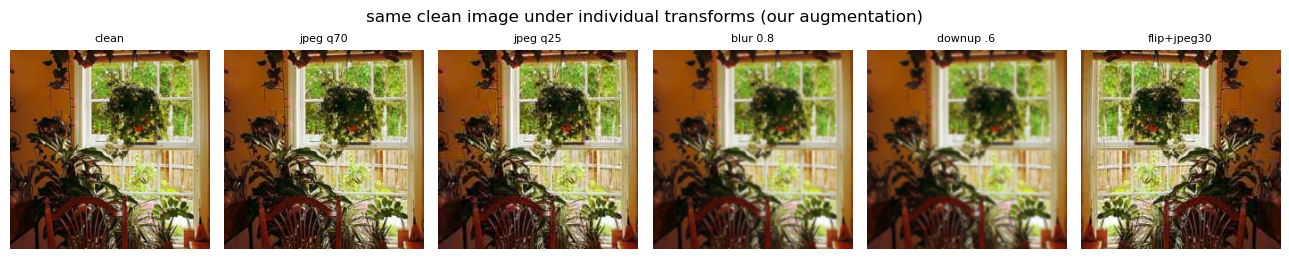

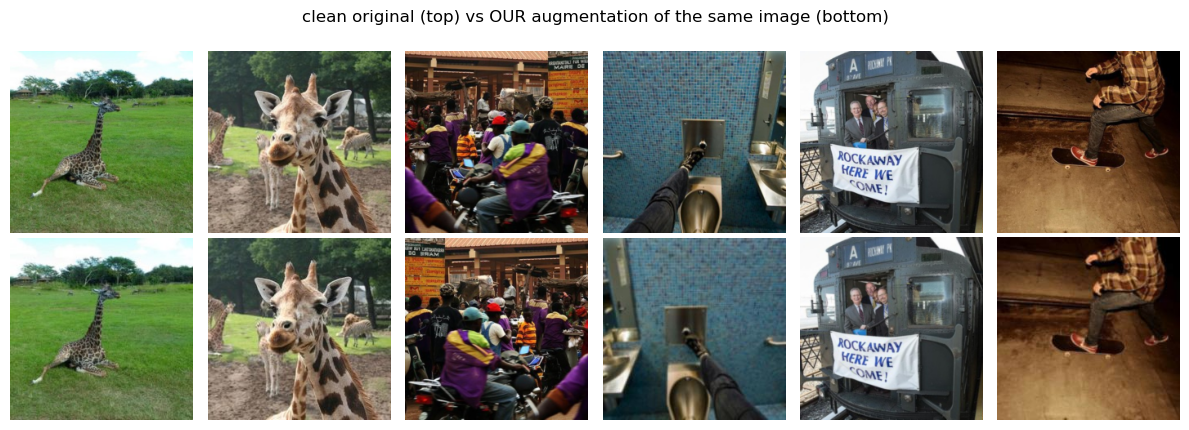

real-class distribution (target = provided augmented):
  clean          hf med=0.0046 p90=0.0101  noise med=0.0349  near-clean=0.75
  provided-aug   hf med=0.0019 p90=0.0091  noise med=0.0194  near-clean=0.43
  OUR-aug        hf med=0.0018 p90=0.0077  noise med=0.0219  near-clean=0.39


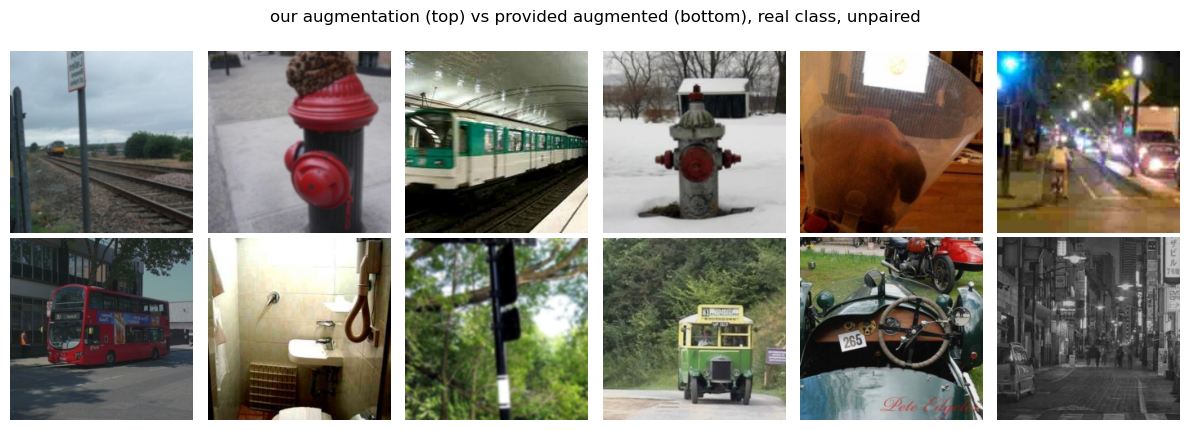

saved augmentation figures to ..\report\figures


In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
FIGS = Path("../report/figures"); FIGS.mkdir(parents=True, exist_ok=True)

# compact metric helpers (chunked) for the population check
_FFTMASK = (np.sqrt(np.add.outer(np.fft.fftfreq(224)**2, np.fft.fftfreq(224)**2)) > 0.25)
def _hf1(X):
    g = (0.299*X[...,0]+0.587*X[...,1]+0.114*X[...,2]).astype(np.float32)/255.0
    sp = np.abs(np.fft.fft2(g, axes=(1,2)))**2
    return sp[:, _FFTMASK].sum(1)/(sp.reshape(len(g),-1).sum(1)+1e-9)
def hf(X):  return np.concatenate([_hf1(X[i:i+200]) for i in range(0, len(X), 200)])
def _ns1(X):
    g = (0.299*X[...,0]+0.587*X[...,1]+0.114*X[...,2]).astype(np.float32)/255.0
    bl=(g[:,:-2,:-2]+g[:,:-2,1:-1]+g[:,:-2,2:]+g[:,1:-1,:-2]+g[:,1:-1,1:-1]+g[:,1:-1,2:]+g[:,2:,:-2]+g[:,2:,1:-1]+g[:,2:,2:])/9
    return (g[:,1:-1,1:-1]-bl).reshape(len(g),-1).std(1)
def noise(X): return np.concatenate([_ns1(X[i:i+200]) for i in range(0, len(X), 200)])

# single-transform helpers for the strength strip
def _jpeg(im_u8, q):
    b=_stdio.BytesIO(); Image.fromarray(im_u8).save(b,"JPEG",quality=q); return np.asarray(Image.open(b).convert("RGB"))
def _blur(im_u8, s): return np.asarray(Image.fromarray(im_u8).filter(ImageFilter.GaussianBlur(s)))
def _downup(im_u8, f):
    im=Image.fromarray(im_u8); w=im.width
    return np.asarray(im.resize((int(w*f),)*2, Image.BILINEAR).resize((w,w), Image.BILINEAR))

rng_v = np.random.default_rng(0)
cr = X_cal[y_cal==0]; ar = X_ca[y_ca==0]            # clean reals, provided augmented reals

# (1) strength strip on one clean image
base = cr[int(rng_v.integers(len(cr)))]
strip = [("clean", base), ("jpeg q70", _jpeg(base,70)), ("jpeg q25", _jpeg(base,25)),
         ("blur 0.8", _blur(base,0.8)), ("downup .6", _downup(base,0.6)),
         ("flip+jpeg30", _jpeg(np.asarray(Image.fromarray(base).transpose(Image.FLIP_LEFT_RIGHT)),30))]
fig, ax = plt.subplots(1, 6, figsize=(13, 2.6))
for a,(t,im) in zip(ax, strip): a.imshow(im); a.set_title(t, fontsize=8); a.axis("off")
fig.suptitle("same clean image under individual transforms (our augmentation)")
fig.tight_layout(); fig.savefig(FIGS/"aug_strength_strip.png", dpi=120, bbox_inches="tight"); plt.show()

# (2) paired clean vs our random augmentation (same image)
idx = rng_v.choice(len(cr), 6, replace=False)
fig, ax = plt.subplots(2, 6, figsize=(12, 4.4))
for j,k in enumerate(idx):
    ax[0,j].imshow(cr[k]); ax[0,j].axis("off")
    ax[1,j].imshow(augment_one(cr[k], np.random.default_rng(100+j))); ax[1,j].axis("off")
fig.suptitle("clean original (top) vs OUR augmentation of the same image (bottom)")
fig.tight_layout(); fig.savefig(FIGS/"ours_paired_real.png", dpi=110, bbox_inches="tight"); plt.show()

# (3) population check: our augmentation vs provided augmented
ours = augment_batch(cr, np.random.default_rng(0))
thr_bare = np.percentile(hf(cr), 25)
def stat(name, X):
    h = hf(X)
    print(f"  {name:14s} hf med={np.median(h):.4f} p90={np.percentile(h,90):.4f}  "
          f"noise med={np.median(noise(X)):.4f}  near-clean={ (h>=thr_bare).mean():.2f}")
print("real-class distribution (target = provided augmented):")
stat("clean", cr); stat("provided-aug", ar); stat("OUR-aug", ours)

ia = rng_v.choice(len(ours), 6, replace=False); ib = rng_v.choice(len(ar), 6, replace=False)
fig, ax = plt.subplots(2, 6, figsize=(12, 4.4))
for j in range(6):
    ax[0,j].imshow(ours[ia[j]]); ax[0,j].axis("off")
    ax[1,j].imshow(ar[ib[j]]);   ax[1,j].axis("off")
fig.suptitle("our augmentation (top) vs provided augmented (bottom), real class, unpaired")
fig.tight_layout(); fig.savefig(FIGS/"ours_vs_provided_real.png", dpi=110, bbox_inches="tight"); plt.show()
print("saved augmentation figures to", FIGS)


## B.3 - Robustness-aware model selection set

Build a deterministic augmented holdout by applying our augmentation once (fixed seed) to the clean `hold` fold. Checkpoint selection and early stopping during fine-tuning use recall on this augmented holdout, so we pick the most robust checkpoint without ever touching `calibration_augmented` or `validation_augmented`. Cached so reruns are fast.

In [5]:
hold_aug_path = NBCACHE / "hold_aug_x.uint8.npy"
if hold_aug_path.exists():
    X_hold_aug = np.load(hold_aug_path)
else:
    X_hold_aug = augment_batch(np.asarray(X_hold), np.random.default_rng(12345))
    np.save(hold_aug_path, X_hold_aug)
print(f"augmented holdout: {X_hold_aug.shape}")
print(f"  hf median  clean hold={np.median(hf(np.asarray(X_hold[:500]))):.4f}  "
      f"aug hold={np.median(hf(X_hold_aug[:500])):.4f}  (drop confirms augmentation applied)")


augmented holdout: (2970, 224, 224, 3)
  hf median  clean hold=0.0034  aug hold=0.0015  (drop confirms augmentation applied)


## B.4 - Task 2 baseline (the "before")

Evaluate the loaded Task 2 ensemble (CNN + RF, alpha and threshold as shipped in `artifacts/task02/`) on `validation` and `validation_augmented`. This reproduces the report Table 2 numbers and is the baseline the Task 3 model must beat on `va` (target recall_ai >= 0.60 at fpr_real <= 0.20).

In [6]:
def metrics(y, scores, thr):
    yp = (scores >= thr).astype(int)
    tp = int(((yp==1)&(y==1)).sum()); fn = int(((yp==0)&(y==1)).sum())
    fp = int(((yp==1)&(y==0)).sum()); tn = int(((yp==0)&(y==0)).sum())
    rec = tp/(tp+fn) if tp+fn else 0.0
    fpr = fp/(fp+tn) if fp+tn else 0.0
    auc = float(roc_auc_score(y, scores)) if len(np.unique(y))>1 else float("nan")
    return rec, fpr, auc

T2_IMG = ckpt["img_size"]; T2_ALPHA = thr_t2["alpha"]; T2_THR = thr_t2["thr"]

def t2_cnn(X):  return cnn_scores(cnn_t2, X, mean, std, target_size=T2_IMG)
def t2_rf(Fm):  return rf_t2.predict_proba(Fm)[:, 1]
def t2_ens(X, Fm): return T2_ALPHA * t2_cnn(X) + (1 - T2_ALPHA) * t2_rf(Fm)

print(f"Task 2 baseline (alpha={T2_ALPHA}, thr={T2_THR:.4f}, calibrated on clean calibration):")
base_results = {}
for tag, X, y, Fm in [("val", X_val, y_val, F_val), ("va", X_va, y_va, F_va)]:
    rec, fpr, auc = metrics(y, t2_ens(X, Fm), T2_THR)
    base_results[tag] = (rec, fpr, auc)
    print(f"  ENS {tag:3s}: recall_ai={rec:.3f}  fpr_real={fpr:.3f}  auc={auc:.3f}")
print("(va is the bar to beat: need recall>=0.60 at fpr<=0.20)")


Task 2 baseline (alpha=0.4, thr=0.6770, calibrated on clean calibration):
  ENS val: recall_ai=0.812  fpr_real=0.165  auc=0.894
  ENS va : recall_ai=0.685  fpr_real=0.374  auc=0.744
(va is the bar to beat: need recall>=0.60 at fpr<=0.20)


## B.5 - Fine-tune from Task 2 with augmentation

Load `artifacts/task02/best.pt` and continue training with on-the-fly augmentation on every batch. Lower LR (1e-4) than from-scratch since we start converged. Same architecture (5-conv BN, k=16, 160px, FocalLoss gamma=1.5) and the same 5x reference budget. Checkpoint selection uses recall on the augmented holdout (B.3), so we keep the most robust model. Best state cached to `notebook_cache/cnn_aug.pt`.

Set `FT_BUDGET_S` lower for a quick smoke test before committing the full budget.

In [7]:
def train_aug(init_state, budget_s, lr=1e-4, P=AUG, batch=64,
              eval_every_s=30.0, patience=10, seed=0, verbose=True):
    """Fine-tune CNN with on-the-fly augmentation; select best by augmented-holdout recall."""
    _seed.set_deterministic(seed)
    cnn = build_cnn_bn(k=CNN_K)
    if init_state is not None:
        cnn.load_state_dict(init_state)
    opt = torch.optim.AdamW(cnn.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = FocalLoss(gamma=1.5, weight=class_weights(y_fit))
    yt = torch.from_numpy(y_fit).long()
    n = len(X_fit); rng_t = np.random.default_rng(seed)
    best = {"recall": -1.0, "state": None, "step": 0}
    deadline = time.monotonic() + budget_s
    last_eval = time.monotonic(); no_improve = 0; step = 0; stop = False
    cnn.train()
    while time.monotonic() < deadline and not stop:
        perm = np.random.permutation(n)
        for i in range(0, n, batch):
            if time.monotonic() >= deadline:
                break
            ix = perm[i:i+batch]
            xb = augment_batch(X_fit[ix], rng_t, P)
            xt = batch_to_chw(np.arange(len(ix)), xb, mean, std, target_size=TRAIN_IMG_SIZE)
            opt.zero_grad(); loss_fn(cnn(xt), yt[ix]).backward(); opt.step(); step += 1
            if time.monotonic() - last_eval >= eval_every_s:
                sc = cnn_scores(cnn, X_hold_aug, mean, std, target_size=TRAIN_IMG_SIZE)
                thr = pick_threshold_for_fpr(sc[y_hold == 0], target_fpr=0.20)
                rec = float(((sc >= thr) & (y_hold == 1)).sum() / max(int((y_hold == 1).sum()), 1))
                if rec > best["recall"] + 1e-4:
                    best = {"recall": rec, "state": {k: v.clone() for k, v in cnn.state_dict().items()}, "step": step}
                    no_improve = 0
                else:
                    no_improve += 1
                if verbose:
                    print(f"  step={step:5d}  aug-holdout recall={rec:.3f}  best={best['recall']:.3f}")
                cnn.train(); last_eval = time.monotonic()
                if no_improve >= patience:
                    if verbose: print(f"  early stop ({patience} evals without improvement)")
                    stop = True; break
    if best["state"] is None:
        best["state"] = {k: v.clone() for k, v in cnn.state_dict().items()}
    cnn.load_state_dict(best["state"])
    return cnn, best, step

FT_BUDGET_S = BUDGET_S          # lower (e.g. 120) for a quick smoke test
print(f"fine-tuning with augmentation for ~{FT_BUDGET_S:.0f}s ...")
_t0 = time.monotonic()
cnn_aug, best_aug, n_steps = train_aug(ckpt["state"], budget_s=FT_BUDGET_S, lr=1e-4)
print(f"done: {n_steps} steps in {time.monotonic()-_t0:.0f}s  best aug-holdout recall={best_aug['recall']:.3f}")
torch.save({"state": best_aug["state"], "k": CNN_K, "img_size": TRAIN_IMG_SIZE, "mean": mean, "std": std},
           str(NBCACHE / "cnn_aug.pt"))
print("saved", NBCACHE / "cnn_aug.pt")


fine-tuning with augmentation for ~778s ...
  step=   45  aug-holdout recall=0.725  best=0.725
  step=   90  aug-holdout recall=0.752  best=0.752
  step=  135  aug-holdout recall=0.768  best=0.768
  step=  180  aug-holdout recall=0.755  best=0.768
  step=  225  aug-holdout recall=0.761  best=0.768
  step=  270  aug-holdout recall=0.771  best=0.771
  step=  316  aug-holdout recall=0.781  best=0.781
  step=  360  aug-holdout recall=0.769  best=0.781
  step=  405  aug-holdout recall=0.774  best=0.781
  step=  452  aug-holdout recall=0.743  best=0.781
  step=  501  aug-holdout recall=0.764  best=0.781
  step=  549  aug-holdout recall=0.760  best=0.781
  step=  598  aug-holdout recall=0.789  best=0.789
  step=  647  aug-holdout recall=0.793  best=0.793
  step=  696  aug-holdout recall=0.797  best=0.797
  step=  744  aug-holdout recall=0.779  best=0.797
  step=  788  aug-holdout recall=0.796  best=0.797
  step=  838  aug-holdout recall=0.798  best=0.798
  step=  887  aug-holdout recall=0.803

## B.6 - Augmentation ablation

Which transforms actually help robustness? Fine-tune for a short fixed budget under each augmentation variant (drop one family at a time) and report recall on the augmented holdout plus recall/fpr on `validation_augmented` (CNN-only, threshold calibrated on `calibration_augmented`). Selection signal is the augmented holdout; `va` is reported for context only. Lower `ABLATION_BUDGET_S` keeps total time bounded.

In [8]:
def cnn_scores_aug(cnn, X): return cnn_scores(cnn, X, mean, std, target_size=TRAIN_IMG_SIZE)

def calibrate_cnn(cnn, target_fpr=0.19):
    """Threshold for a CNN from calibration_augmented reals."""
    pc = cnn_scores_aug(cnn, X_ca)
    return pick_threshold_for_fpr(pc[y_ca == 0], target_fpr)

def eval_cnn(cnn, thr=None):
    if thr is None: thr = calibrate_cnn(cnn)
    out = {}
    for tag, X, y in [("val", X_val, y_val), ("va", X_va, y_va), ("hold_aug", X_hold_aug, y_hold)]:
        out[tag] = metrics(y, cnn_scores_aug(cnn, X), thr)
    return thr, out

ABLATION_BUDGET_S = 90
ablation_cfgs = {
    "full":      AUG,
    "no_jpeg":   {**AUG, "p_jpeg": 0.0},
    "no_blur":   {**AUG, "p_blur": 0.0},
    "no_down":   {**AUG, "p_down": 0.0},
    "jpeg_only": {**AUG, "p_blur": 0.0, "p_down": 0.0, "p_photo": 0.0, "p_flip": 0.0},
    "none":      {k: (0.0 if k.startswith("p_") else v) for k, v in AUG.items()},
}
print(f"ablation ({ABLATION_BUDGET_S}s/config, CNN-only, thr from calibration_augmented):")
print(f"  {'config':10s}  {'aug-hold rec':>12s}  {'va rec':>7s}  {'va fpr':>7s}  {'val rec':>7s}  {'val fpr':>7s}")
abl_rows = {}
for name, P in ablation_cfgs.items():
    cnn_a, best_a, _ = train_aug(ckpt["state"], ABLATION_BUDGET_S, lr=1e-4, P=P, verbose=False)
    _, out = eval_cnn(cnn_a)
    abl_rows[name] = out
    print(f"  {name:10s}  {best_a['recall']:>12.3f}  {out['va'][0]:>7.3f}  {out['va'][1]:>7.3f}  "
          f"{out['val'][0]:>7.3f}  {out['val'][1]:>7.3f}")


ablation (90s/config, CNN-only, thr from calibration_augmented):
  config      aug-hold rec   va rec   va fpr  val rec  val fpr
  full               0.761    0.487    0.176    0.521    0.064
  no_jpeg            0.760    0.496    0.187    0.603    0.080
  no_blur            0.735    0.503    0.203    0.587    0.064
  no_down            0.749    0.501    0.176    0.582    0.074
  jpeg_only          0.707    0.489    0.182    0.549    0.059
  none               0.669    0.507    0.155    0.540    0.048


## B.7 - Composition: CNN-only vs ensemble

Compare three Task 3 models, all thresholded on `calibration_augmented`: (a) robust CNN alone; (b) robust CNN + the Task 2 RF; (c) robust CNN + an RF retrained on augmented features. RF features (FFT, JPEG-block) are exactly what the shift degrades, so RF may hurt under augmentation. Ensemble alpha is chosen by AUC on the augmented holdout (not on `va`). We keep whichever passes fpr<=0.20 with the best augmented-holdout recall; `val`/`va` reported for context.

In [9]:
from sklearn.ensemble import RandomForestClassifier

# features for calibration_augmented and the augmented holdout (needed for any RF ensemble)
F_ca       = features_from_uint8(X_ca)
F_hold_aug = features_from_uint8(X_hold_aug)

def select_alpha(pc, pr, y):
    best_a, best_auc = 0.4, -1.0
    for a in (0.3, 0.4, 0.5, 0.6, 0.7):
        auc = float(roc_auc_score(y, a*pc + (1-a)*pr))
        if auc > best_auc: best_a, best_auc = a, auc
    return best_a

def eval_ens(cnn, rf, alpha, target_fpr=0.19):
    pc_ca = cnn_scores_aug(cnn, X_ca); pr_ca = rf.predict_proba(F_ca)[:, 1]
    thr = pick_threshold_for_fpr((alpha*pc_ca + (1-alpha)*pr_ca)[y_ca == 0], target_fpr)
    out = {}
    for tag, X, y, Fm in [("val", X_val, y_val, F_val), ("va", X_va, y_va, F_va),
                          ("hold_aug", X_hold_aug, y_hold, F_hold_aug)]:
        s = alpha*cnn_scores_aug(cnn, X) + (1-alpha)*rf.predict_proba(Fm)[:, 1]
        out[tag] = metrics(y, s, thr)
    return thr, out, alpha

# (a) CNN-only
thr_a, out_a = eval_cnn(cnn_aug)

# (b) robust CNN + Task 2 RF
pc_h = cnn_scores_aug(cnn_aug, X_hold_aug); pr_h_t2 = rf_t2.predict_proba(F_hold_aug)[:, 1]
alpha_b = select_alpha(pc_h, pr_h_t2, y_hold)
thr_b, out_b, _ = eval_ens(cnn_aug, rf_t2, alpha_b)

# (c) robust CNN + RF retrained on augmented features (subsample of fit for speed)
sub = np.sort(np.random.default_rng(0).choice(len(X_fit), min(10000, len(X_fit)), replace=False))
F_fit_aug = features_from_uint8(augment_batch(X_fit[sub], np.random.default_rng(7)))
rf_aug = RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=0,
                                class_weight="balanced", max_features="sqrt").fit(F_fit_aug, y_fit[sub])
pr_h_aug = rf_aug.predict_proba(F_hold_aug)[:, 1]
alpha_c = select_alpha(pc_h, pr_h_aug, y_hold)
thr_c, out_c, _ = eval_ens(cnn_aug, rf_aug, alpha_c)

print(f"{'composition':28s}  {'hold_aug rec':>12s}  {'va rec':>7s}  {'va fpr':>7s}  {'val rec':>7s}  {'val fpr':>7s}")
def show(name, out):
    print(f"  {name:26s}  {out['hold_aug'][0]:>12.3f}  {out['va'][0]:>7.3f}  {out['va'][1]:>7.3f}  "
          f"{out['val'][0]:>7.3f}  {out['val'][1]:>7.3f}")
show("CNN-only", out_a)
show(f"CNN + RF_t2 (a={alpha_b})", out_b)
show(f"CNN + RF_aug (a={alpha_c})", out_c)
print("pick: best hold_aug recall with va fpr<=0.20 and val fpr<=0.20")


composition                   hold_aug rec   va rec   va fpr  val rec  val fpr
  CNN-only                           0.739    0.550    0.160    0.642    0.085
  CNN + RF_t2 (a=0.6)                0.795    0.567    0.166    0.700    0.090
  CNN + RF_aug (a=0.7)               0.771    0.568    0.166    0.673    0.096
pick: best hold_aug recall with va fpr<=0.20 and val fpr<=0.20


## B.8 - Final calibration and Task 2 vs Task 3 comparison

Pick the composition from B.7 (set `CHOICE`), calibrate its threshold on `calibration_augmented`, and report the core §1.3 deliverable: Task 2 vs Task 3 on **both** `validation` and `validation_augmented` under the same threshold-calibration protocol. `validation_augmented` is read here for the first time as a reported number (not used for any selection). Target: Task 3 recall_ai >= 0.60 on `va` with fpr_real <= 0.20, ideally without regressing `val`.

In [10]:
CHOICE = "cnn"   # set from B.7 results: "cnn", "ens_t2", or "ens_aug"

choice_map = {
    "cnn":     (thr_a, out_a, "Task3 CNN-only"),
    "ens_t2":  (thr_b, out_b, f"Task3 CNN+RF_t2 (a={alpha_b})"),
    "ens_aug": (thr_c, out_c, f"Task3 CNN+RF_aug (a={alpha_c})"),
}
thr_final, out_final, choice_label = choice_map[CHOICE]
print(f"chosen: {choice_label}   threshold={thr_final:.4f} (calibrated on calibration_augmented)\n")

print(f"{'model':22s} {'split':4s}  {'recall_ai':>9s}  {'fpr_real':>8s}  {'auc':>6s}")
def prow(model, split, tup):
    rec, fpr, auc = tup
    flag = "" if fpr <= 0.20 else "  <-- FPR VIOLATION"
    print(f"{model:22s} {split:4s}  {rec:>9.3f}  {fpr:>8.3f}  {auc:>6.3f}{flag}")
prow("Task2 ensemble", "val", base_results["val"])
prow("Task2 ensemble", "va",  base_results["va"])
prow(choice_label,     "val", out_final["val"])
prow(choice_label,     "va",  out_final["va"])

va_rec, va_fpr, _ = out_final["va"]
ok = (va_rec >= 0.60) and (va_fpr <= 0.20) and (out_final["val"][1] <= 0.20)
print(f"\nTask 3 target on va (recall>=0.60, fpr<=0.20): {'PASS' if ok else 'NOT YET'}")

# persist the chosen Task 3 model + threshold for the script port
import json as _json
torch.save({"state": best_aug["state"], "k": CNN_K, "img_size": TRAIN_IMG_SIZE, "mean": mean, "std": std},
           str(NBCACHE / "cnn_aug.pt"))
_json.dump({"choice": CHOICE, "thr": float(thr_final), "target_fpr": 0.19,
            "alpha": (alpha_b if CHOICE=="ens_t2" else alpha_c if CHOICE=="ens_aug" else None)},
           open(NBCACHE / "task03_choice.json", "w"), indent=2)
print("saved cnn_aug.pt + task03_choice.json to", NBCACHE)


chosen: Task3 CNN-only   threshold=0.4077 (calibrated on calibration_augmented)

model                  split  recall_ai  fpr_real     auc
Task2 ensemble         val       0.812     0.165   0.894
Task2 ensemble         va        0.685     0.374   0.744  <-- FPR VIOLATION
Task3 CNN-only         val       0.642     0.085   0.881
Task3 CNN-only         va        0.550     0.160   0.759

Task 3 target on va (recall>=0.60, fpr<=0.20): NOT YET
saved cnn_aug.pt + task03_choice.json to ..\solution\artifacts\notebook_cache


## B.9 - Budget proof

The shipped Task 3 model is the single fine-tuning run in B.5 (plus an RF retrain only if B.7 selects an augmented ensemble). The ablation (B.6) and composition (B.7) experiments are development-only and not part of the shipped budget. Confirm the fine-tune stays within the 5x reference budget; the script `train_augmented.py` uses the same deadline loop bounded by `timeout_seconds`.

In [11]:
ft_elapsed = best_aug["step"]  # reference; actual wall time printed in B.5
print(f"fine-tune budget   : {FT_BUDGET_S:.0f}s   (5x reference = {BUDGET_S:.0f}s)")
print(f"fine-tune steps    : {n_steps}   best checkpoint at step {best_aug['step']}")
extra = "+ RF retrain (~subsample)" if CHOICE == "ens_aug" else "(CNN-only, no RF retrain)" if CHOICE == "cnn" else "+ reuse Task2 RF"
print(f"shipped Task 3 cost : one fine-tune run {extra}; within the 5x budget")
print(f"augmentation overhead measured in B.2: ~{100*aug_s/step_s:.0f}% per step")


fine-tune budget   : 778s   (5x reference = 778s)
fine-tune steps    : 887   best checkpoint at step 887
shipped Task 3 cost : one fine-tune run (CNN-only, no RF retrain); within the 5x budget
augmentation overhead measured in B.2: ~15% per step


## B.10 - Exit criteria and port targets

**Exit criteria:** B.8 shows Task 3 recall_ai >= 0.60 on `validation_augmented` at fpr_real <= 0.20, with `validation` fpr <= 0.20 and recall not badly regressed vs Task 2.

**Port targets (only after the criteria pass):**
- `solution/_lib/aug.py` (new): `AUG` config + `augment_one` / `augment_batch` (verbatim from B.2).
- `solution/_lib/model.py`: add `train_cnn_augmented` (B.5 loop) reusing `batch_to_chw`, `cnn_scores`, `FocalLoss`, `class_weights`, `build_cnn_bn`; or extend `train_cnn` with an `augment=` callable.
- `solution/prepare.py`: add a `ca` (calibration_augmented) labeled cache + features, mirroring how `va` is built, so `train_augmented.py` can calibrate from the prepared cache.
- `solution/train_augmented.py`: load `artifacts/task02/best.pt`, fine-tune with augmentation under the deadline loop (write `best.pt` regularly), select by augmented-holdout recall, calibrate threshold on `calibration_augmented`, save `artifacts/task03/{best.pt, threshold.json}` (+ `rf_model.pkl` only if `CHOICE` is an ensemble).
- `solution/predict_augmented.py`: load task03 artifacts, run inference on `data/predict/`, write `artifacts/task03/predictions.csv` (CNN-only path if `CHOICE == "cnn"`).
- `report/report.md` §1.3: augmentation rationale (from notebook 04), fine-tune vs scratch note, the B.8 Task2-vs-Task3 table on both splits, and the figures in `report/figures/`.